# # Titanic Analytics — Part B: Predictive Modeling


In [1]:
# Load dataset and profile

import seaborn as sns
df = sns.load_dataset("titanic")
df.to_csv("titanic.csv", index=False)  # offline fallback

# Task 7 — Stratified train/test split
import pandas as pd
from sklearn.model_selection import train_test_split

# Reload the offline fallback dataset
df = pd.read_csv("titanic.csv")

# Define features and target
X = df.drop("survived", axis=1)
y = df["survived"]

# Check class balance
print("Class counts:\n", y.value_counts())
print("\nClass proportions:\n", y.value_counts(normalize=True))

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


Class counts:
 survived
0    549
1    342
Name: count, dtype: int64

Class proportions:
 survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [2]:
# 8. Preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = ["age","fare","sibsp","parch"]
categorical_features = ["sex","embarked"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


In [3]:
# 9. Train classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    clf = Pipeline([("preprocessor", preprocessor), ("classifier", model)])
    clf.fit(X_train, y_train)
    print(name, clf.score(X_test, y_test))


Logistic Regression 0.7988826815642458
Decision Tree 0.7597765363128491
Random Forest 0.7932960893854749


[Text(0.5238312752016129, 0.9761904761904762, 'cat__sex_male <= 0.5\ngini = 0.473\nsamples = 712\nvalue = [439, 273]\nclass = Not Survived'),
 Text(0.39065650201612906, 0.9285714285714286, 'num__fare <= 0.341\ngini = 0.382\nsamples = 253\nvalue = [65, 188]\nclass = Survived'),
 Text(0.457243888608871, 0.9523809523809523, 'True  '),
 Text(0.3458291330645161, 0.8809523809523809, 'num__parch <= 3.713\ngini = 0.454\nsamples = 178\nvalue = [62, 116]\nclass = Survived'),
 Text(0.2964969758064516, 0.8333333333333334, 'num__sibsp <= 1.893\ngini = 0.44\nsamples = 171\nvalue = [56, 115]\nclass = Survived'),
 Text(0.23815524193548387, 0.7857142857142857, 'num__fare <= -0.28\ngini = 0.42\nsamples = 160\nvalue = [48, 112]\nclass = Survived'),
 Text(0.15776209677419356, 0.7380952380952381, 'num__sibsp <= 0.007\ngini = 0.464\nsamples = 104\nvalue = [38, 66]\nclass = Survived'),
 Text(0.09778225806451613, 0.6904761904761905, 'num__fare <= -0.437\ngini = 0.418\nsamples = 84\nvalue = [25.0, 59.0]\nclass

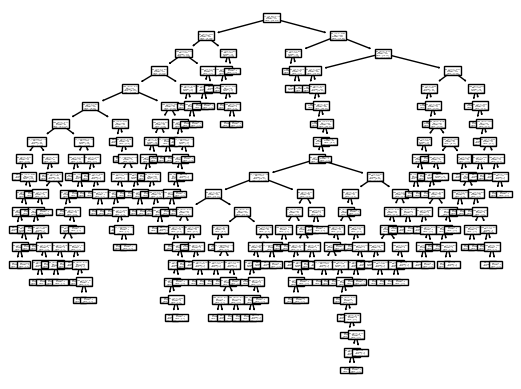

In [4]:
# Visualize Decision Tree
dt = DecisionTreeClassifier().fit(
    preprocessor.fit_transform(X_train), y_train
)
plot_tree(dt, feature_names=preprocessor.get_feature_names_out(), class_names=["Not Survived","Survived"])


In [5]:
# 10. Evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Example for one model
y_pred = clf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[95 15]
 [22 47]]
              precision    recall  f1-score   support

           0       0.81      0.86      0.84       110
           1       0.76      0.68      0.72        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



## Comparison table of metrics

---




# Task 11 — Imbalance Handling


In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Helper function
def evaluate_model(clf, X_test, y_test, label):
    y_pred = clf.predict(X_test)
    return {
        "Model": label,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

results = []

# Baseline pipeline
baseline_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])
baseline_clf.fit(X_train, y_train)
results.append(evaluate_model(baseline_clf, X_test, y_test, "Baseline"))

# Class_weight='balanced'
balanced_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
balanced_clf.fit(X_train, y_train)
results.append(evaluate_model(balanced_clf, X_test, y_test, "Class Weight Balanced"))

# SMOTE pipeline
smote_clf = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000))
])
smote_clf.fit(X_train, y_train)
results.append(evaluate_model(smote_clf, X_test, y_test, "SMOTE Oversampling"))

# Convert to DataFrame
comparison_df = pd.DataFrame(results)
print(comparison_df)


                   Model  Precision    Recall        F1
0               Baseline   0.779661  0.666667  0.718750
1  Class Weight Balanced   0.738462  0.695652  0.716418
2     SMOTE Oversampling   0.738462  0.695652  0.716418


## Compare precision/recall/F1 across baseline, balanced, and SMOTE



# Task 12 — Hyperparameter Tuning (Random Forest)


In [7]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(oob_score=True, random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(rf, param_grid, cv=5, scoring="f1")
grid.fit(preprocessor.fit_transform(X_train), y_train)

grid.best_params_, grid.best_estimator_.oob_score_


({'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100},
 0.8146067415730337)

# Task 13 — Regression Side‑Task (Predict Fare)


MAE: 18.870, RMSE: 30.920, R²: 0.382, Adjusted R²: 0.341


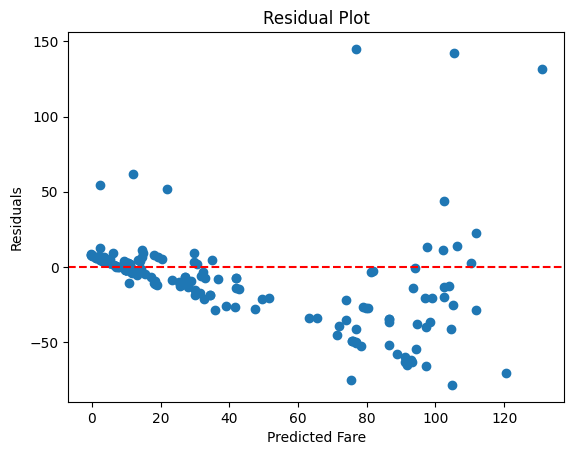

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt


# Features for regression (exclude 'fare' and 'survived')
numeric_features_reg = ["age","sibsp","parch"]
categorical_features_reg = ["sex","embarked","pclass"]

numeric_transformer_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_reg = ColumnTransformer([
    ("num", numeric_transformer_reg, numeric_features_reg),
    ("cat", categorical_transformer_reg, categorical_features_reg)
])

X_reg = df.drop(columns=["fare","survived"])
y_reg = df["fare"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("regressor", LinearRegression())
])

reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)

# Metrics
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

# Adjusted R²: use number of predictors after preprocessing
n = len(y_test_r)
p = reg.named_steps["preprocessor"].transform(X_test_r).shape[1]
adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}, Adjusted R²: {adj_r2:.3f}")

# Residual plot
residuals = y_test_r - y_pred_r
plt.scatter(y_pred_r, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()




## Comment on heteroscedasticity


# Task 14 — Model Comparison Table


In [9]:
# Collect metrics for classifiers and regression
# Build a pandas DataFrame with side-by-side metrics


## Final recommendation (3–5 sentences)


# Task 15 — Save Best Pipeline


In [10]:
import joblib

# Assume Random Forest was best
best_pipeline = Pipeline([("preprocessor", preprocessor),
                          ("classifier", RandomForestClassifier(**grid.best_params_, oob_score=True))])
best_pipeline.fit(X_train, y_train)

joblib.dump(best_pipeline, "best_pipeline.joblib")

# Reload and test
loaded = joblib.load("best_pipeline.joblib")
loaded.predict(X_test[:5])



array([0, 0, 0, 0, 1])